In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.stats import pearsonr, spearmanr, kendalltau
import umap

from dti import data
from dti.utils import init_logging
from dti.constants import SMILES, ASSAY, ACT

init_logging()
sns.set_context("talk")

data_path = Path("..") / "data" / "raw"

# df = data.load_nci(data_path / "atcc.csv")

df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")

from multiprocessing import Pool
from dti.utils import compute_fp

with Pool(8) as p:
    fp_list = p.map(compute_fp, df[SMILES].values)

df = df[[fp is not None for fp in fp_list]]

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

pca = PCA(n_components=15)
fp_list = [fp for fp in fp_list if fp is not None]
pcs = pca.fit_transform(np.stack(fp_list))

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(pcs)

In [34]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=50)  # Adjust size as needed
df["_umap"] = clusterer.fit_predict(embedding)

/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [29]:
from sklearn.cluster import KMeans

In [31]:
clustering = KMeans(n_clusters=10)
clusters = clustering.fit_predict(embedding)

In [36]:
(df["_umap"] == -1).mean()

np.float64(0.42100876754342104)

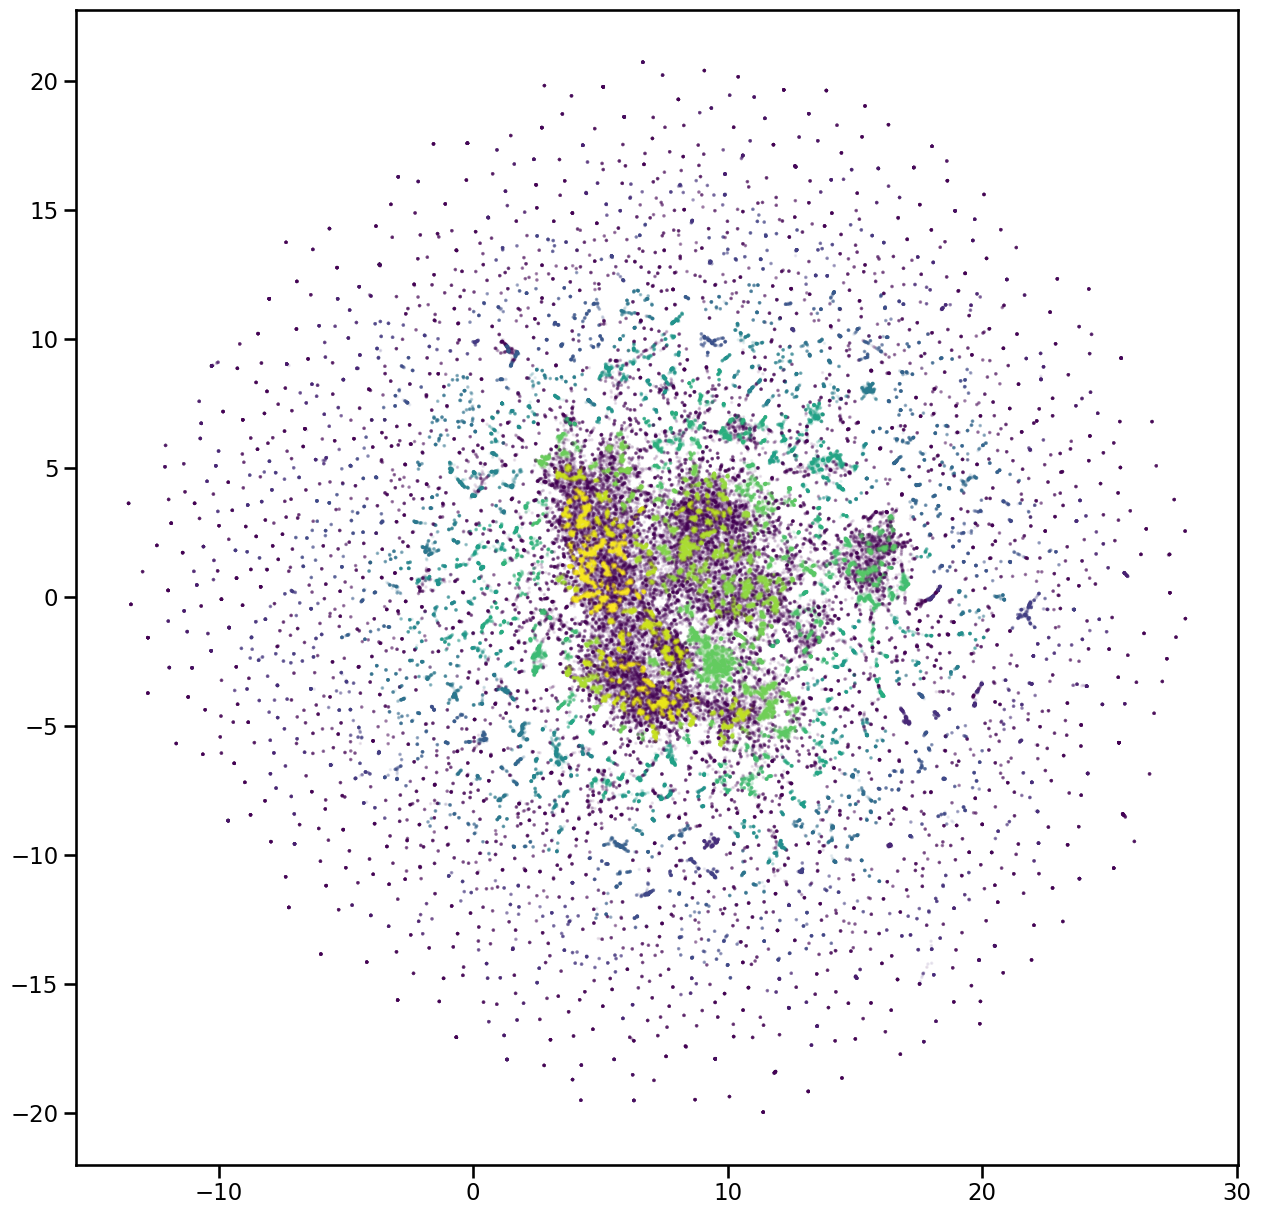

In [37]:
plt.figure(figsize=(15, 15))
plt.scatter(*embedding.T, s=1, alpha=0.1, c=df["_umap"])

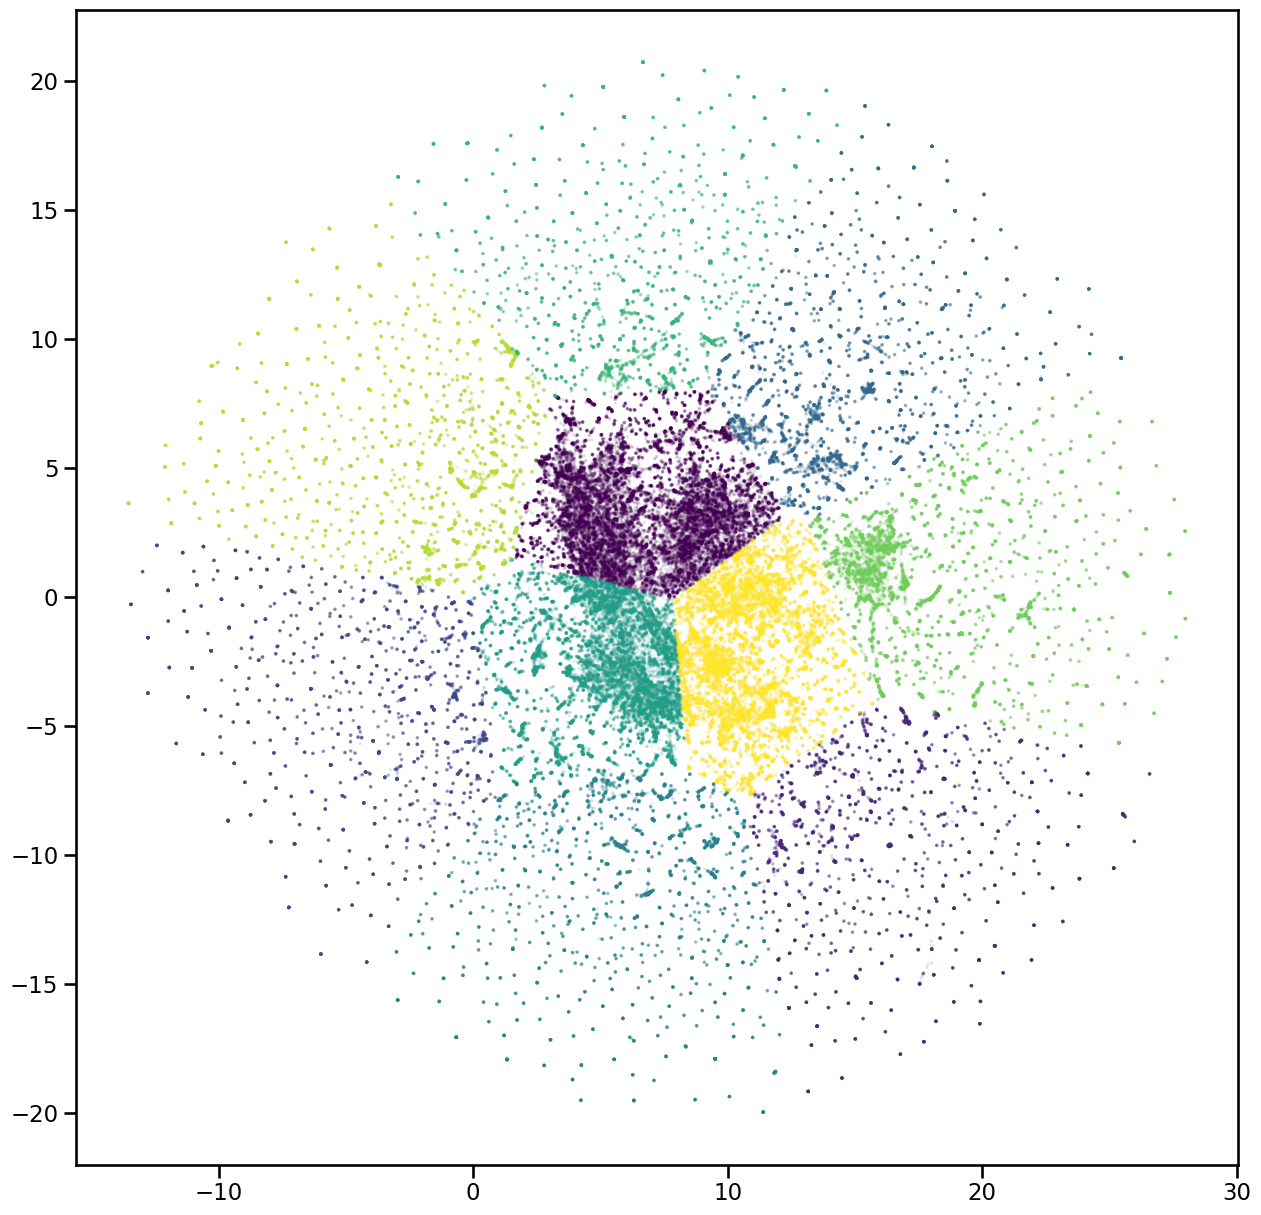

In [32]:
plt.figure(figsize=(15, 15))
plt.scatter(*embedding.T, s=1, alpha=0.1, c=clusters)

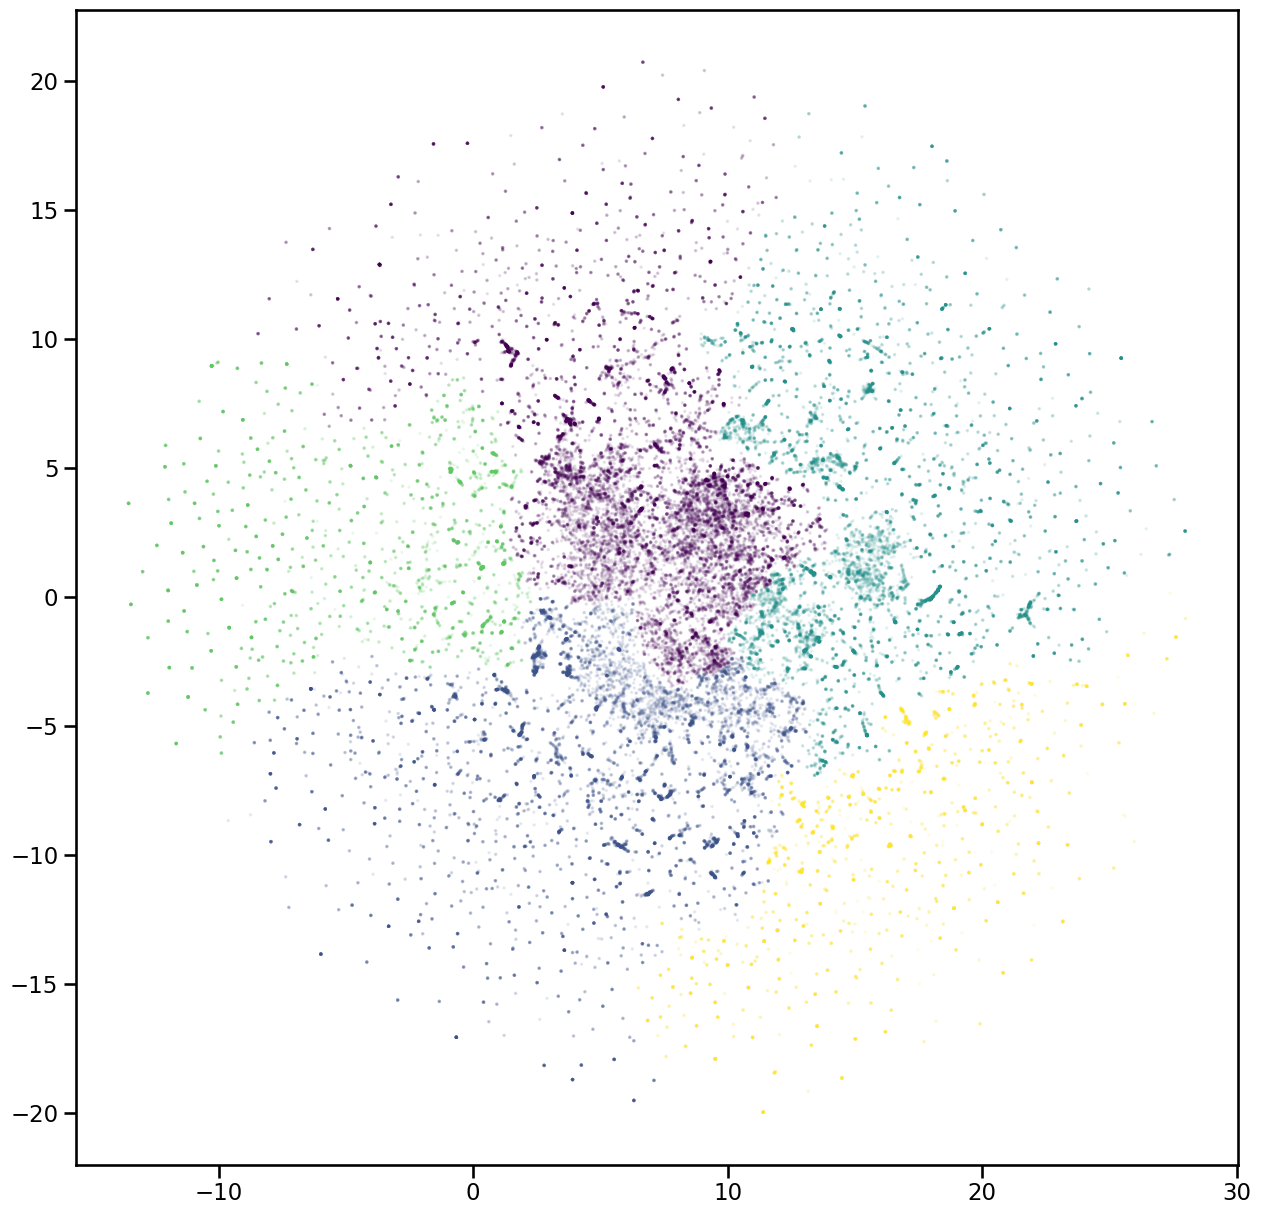

In [42]:
N = 60_000
ac = AgglomerativeClustering(n_clusters=5, compute_full_tree=False)
ac.fit_predict(embedding[:N])
# data['_umap'] = ac.labels_

plt.figure(figsize=(15, 15))
plt.scatter(*embedding[:N].T, s=1, alpha=0.1, c=ac.labels_)

In [43]:
df = df.head(N)
df["_umap"] = ac.labels_

/tmp/ipykernel_4311/442855911.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['_umap'] = ac.labels_


In [46]:
for test_cluster in range(5):
    df_train, df_test = df[df["_umap"] != test_cluster], df[df["_umap"] == test_cluster]

    training_mean = df_train[ACT].mean()
    predictor = df_train.groupby(ASSAY)[[ACT]].agg("mean")
    df_test = df_test.join(
        predictor.rename(columns={ACT: "assay_mean"}), on=ASSAY, how="left"
    )

    xs, ys = df_test["activity_value"].values, df_test["assay_mean"].values
    xs = xs[~np.isnan(ys)]
    ys = ys[~np.isnan(ys)]
    assert np.all(~np.isnan(xs))
    mae = np.abs(xs - ys).mean()
    pr = pearsonr(xs, ys).statistic
    kt = kendalltau(xs, ys).statistic
    sr = spearmanr(xs, ys).statistic
    print("===", test_cluster)
    print(f"Pearson={pr:.2f}\nSpearman={sr:.2f}\nMAE={mae:.2f}\nKendall's tau={kt:.2f}")

=== 0
Pearson=0.57
Spearman=0.49
MAE=0.38
Kendall's tau=0.35
=== 1
Pearson=0.60
Spearman=0.52
MAE=0.38
Kendall's tau=0.37
=== 2
Pearson=0.54
Spearman=0.50
MAE=0.37
Kendall's tau=0.36
=== 3
Pearson=0.60
Spearman=0.51
MAE=0.34
Kendall's tau=0.37
=== 4
Pearson=0.62
Spearman=0.52
MAE=0.38
Kendall's tau=0.37


R2=0.62
Spearman=0.52
MAE=0.38
Kendall's tau=0.37


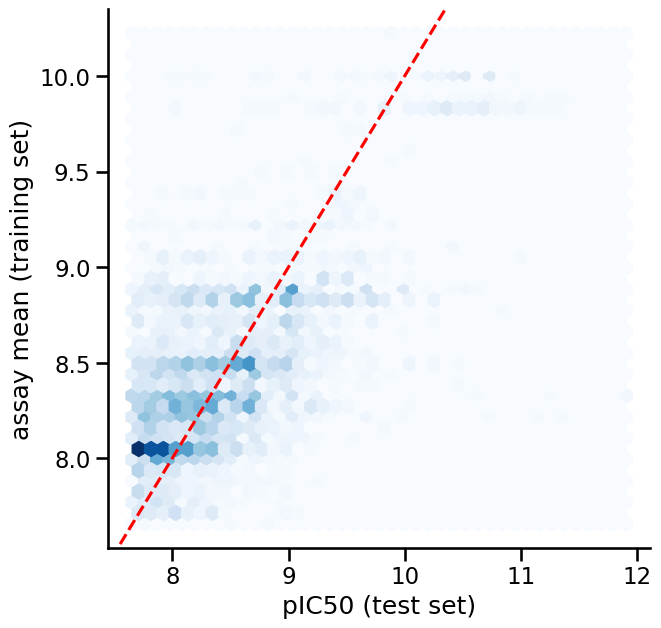

In [48]:
plt.figure(figsize=(7, 7))
xs, ys = df_test["activity_value"].values, df_test["assay_mean"].values
plt.hexbin(xs, ys, gridsize=40, cmap="Blues")
sns.despine()
xl = plt.xlim()
yl = plt.ylim()
plt.plot([0, 15], [0, 15], "r--")
plt.xlim(*xl)
plt.ylim(*yl)
plt.ylabel("assay mean (training set)")
plt.xlabel("pIC50 (test set)")
xs = xs[~np.isnan(ys)]
ys = ys[~np.isnan(ys)]
assert np.all(~np.isnan(xs))
mae = np.abs(xs - ys).mean()
pr = pearsonr(xs, ys).statistic
kt = kendalltau(xs, ys).statistic
sr = spearmanr(xs, ys).statistic
print(f"R2={pr:.2f}\nSpearman={sr:.2f}\nMAE={mae:.2f}\nKendall's tau={kt:.2f}")

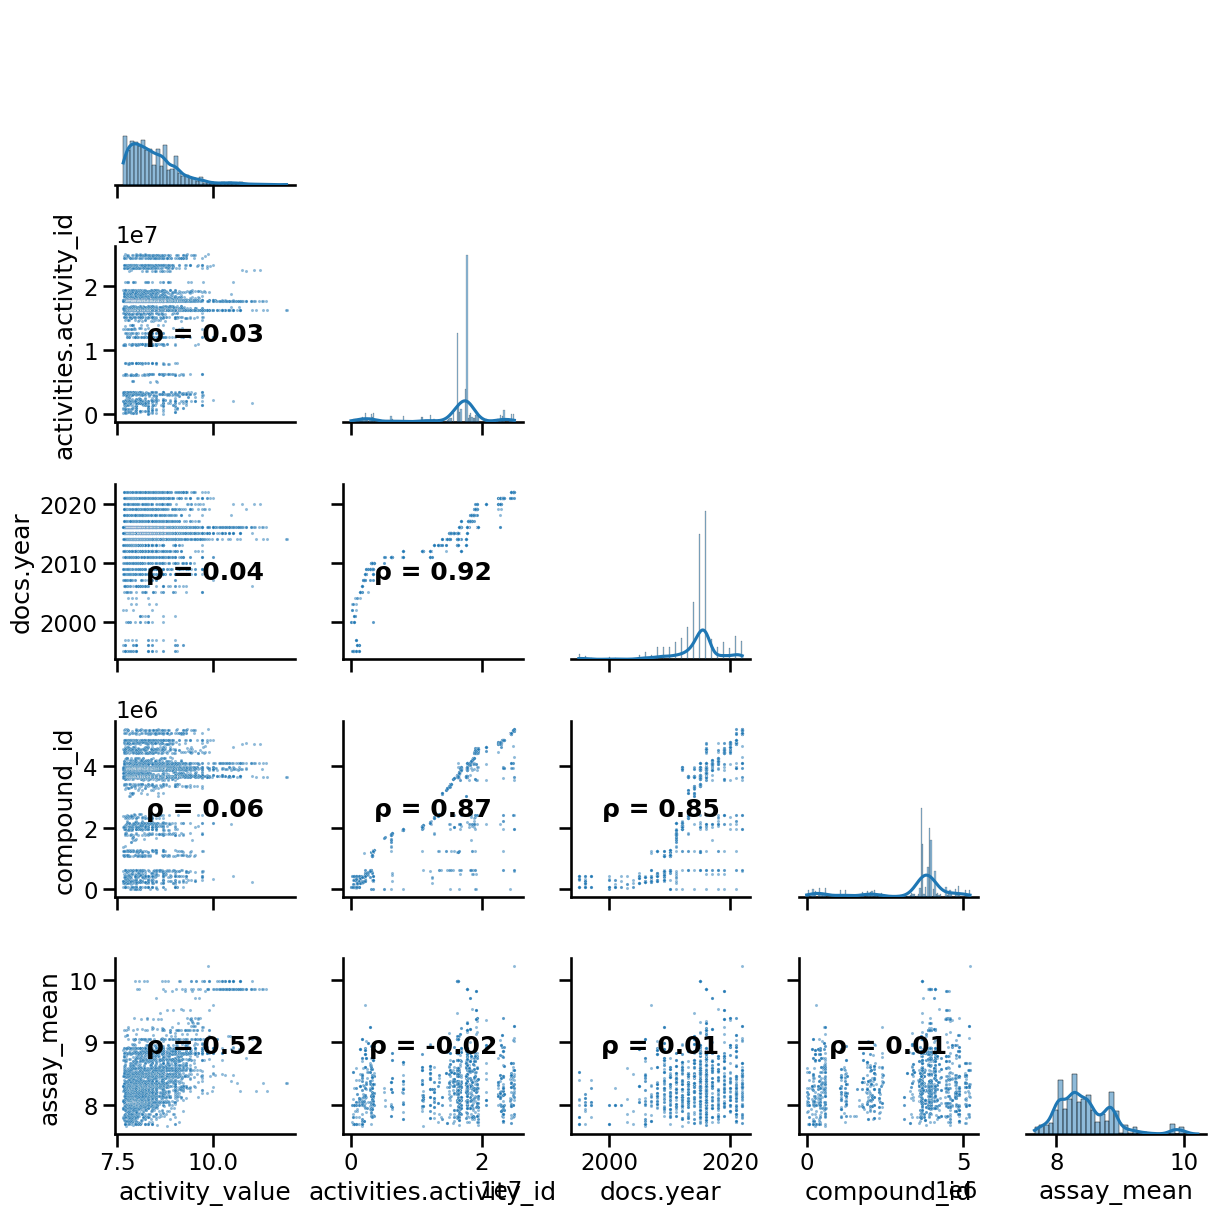

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def corrfunc(x, y, **kws):
    corr = spearmanr(x, y, nan_policy="omit").statistic
    ax = plt.gca()
    ax.annotate(
        f"ρ = {corr:.2f}",
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
    )


cols = [ACT, "activities.activity_id", "docs.year", "compound_id", "assay_mean"]
df_filtered = df_test[df_test["docs.year"] > 1950][cols]

g = sns.PairGrid(df_filtered, corner=True)

g.map_lower(sns.scatterplot, s=5, alpha=0.5)
g.map_offdiag(corrfunc)
g.map_diag(sns.histplot, kde=True)

plt.tight_layout()
plt.savefig("pair.png")